In [ ]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.13 ultralytics opencv-python numpy pandas matplotlib

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# MediaPipe Pose initialisation
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)
mp_drawing = mp.solutions.drawing_utils

# YOLO model initialisation
yolo_model = YOLO("yolov8n.pt")

print("Models loaded ✅")

Models loaded ✅


Saving Screenshot 2026-04-01 153016.png to Screenshot 2026-04-01 153016.png


(np.float64(-0.5), np.float64(1171.5), np.float64(611.5), np.float64(-0.5))

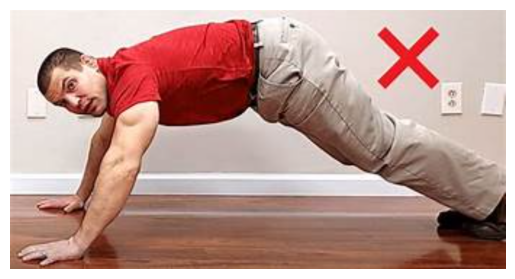

In [ ]:
from IPython.display import display
from PIL import Image

# Upload file from your system
from google.colab import files  # (works in Colab)
uploaded = files.upload()

# Get filename
image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)

if image is None:
    raise ValueError("Image not found!")

# Convert BGR → RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")

In [ ]:
#detect human body using YOLO

results = yolo_model(image)

person_boxes = []

for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])

        # class 0 = person
        if cls == 0:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            person_boxes.append((x1, y1, x2, y2))

print("Detected persons:", len(person_boxes))


0: 352x640 1 person, 153.3ms
Speed: 5.0ms preprocess, 153.3ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)
Detected persons: 1


(np.float64(-0.5), np.float64(1171.5), np.float64(611.5), np.float64(-0.5))

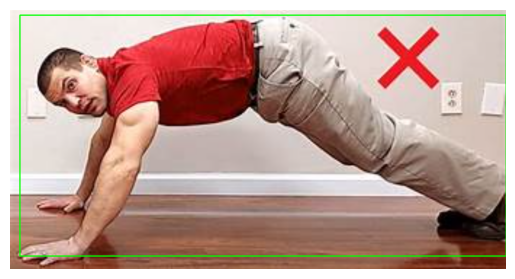

In [ ]:
#Visualise the detection in boxes
output_img = image.copy()

for (x1, y1, x2, y2) in person_boxes:
    cv2.rectangle(output_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

(np.float64(-0.5), np.float64(1148.5), np.float64(566.5), np.float64(-0.5))

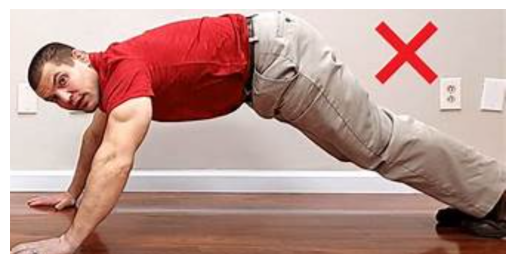

In [ ]:
#crop the image of main Body
if len(person_boxes) == 0:
    raise ValueError("No person detected!")

x1, y1, x2, y2 = person_boxes[0]  # first person

cropped = image[y1:y2, x1:x2]
cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

plt.imshow(cropped_rgb)
plt.axis("off")

(np.float64(-0.5), np.float64(1148.5), np.float64(566.5), np.float64(-0.5))

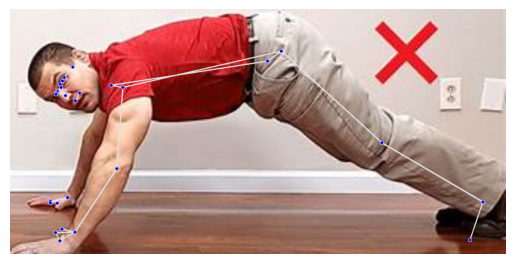

In [ ]:
#show 33 points with skeletal image

results_pose = pose.process(cropped_rgb)

if not results_pose.pose_landmarks:
    raise ValueError("Pose not detected!")

# Draw landmarks
annotated = cropped_rgb.copy()
mp_drawing.draw_landmarks(
    annotated,
    results_pose.pose_landmarks,
    mp_pose.POSE_CONNECTIONS
)

plt.imshow(annotated)
plt.axis("off")

In [ ]:
#Extract all keypoints

keypoints = []

for lm in results_pose.pose_landmarks.landmark:
    keypoints.append([lm.x, lm.y, lm.z])

keypoints = np.array(keypoints)

In [ ]:
#Normalisation accourding to hip and shoulder
# Centering using hip midpoint
left_hip = keypoints[23]
right_hip = keypoints[24]
center = (left_hip + right_hip) / 2

keypoints_shifted = keypoints - center

# Scale using shoulders
left_shoulder = keypoints[11]
right_shoulder = keypoints[12]

torso_size = np.linalg.norm(left_shoulder - right_shoulder)

keypoints_normalized = keypoints_shifted / (torso_size + 1e-6)

In [ ]:
#calculate angles of joints

def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    angle = np.arccos(cosine)

    return np.degrees(angle)

In [ ]:
def get_point(idx):
    return keypoints_normalized[idx][:2]

In [ ]:
# Elbows
left_elbow = calculate_angle(get_point(11), get_point(13), get_point(15))
right_elbow = calculate_angle(get_point(12), get_point(14), get_point(16))

# Knees
left_knee = calculate_angle(get_point(23), get_point(25), get_point(27))
right_knee = calculate_angle(get_point(24), get_point(26), get_point(28))

# Hips
left_hip_angle = calculate_angle(get_point(11), get_point(23), get_point(25))
right_hip_angle = calculate_angle(get_point(12), get_point(24), get_point(26))

print("Angles extracted ✅")

Angles extracted ✅


In [ ]:
#import model for classification

from google.colab import drive
from tensorflow.keras.models import load_model
import os

# Mount Google Drive
drive.mount('/content/drive')

# Path to your model
model_path = "/content/drive/MyDrive/exercise_model.h5"

# Check if file exists (prevents crash ❗)
if not os.path.exists(model_path):
    raise FileNotFoundError("Model file not found! Check your path.")

# Load model
model = load_model(model_path)

print("Model loaded successfully ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded successfully ✅


In [ ]:
#Predict exercise using Model

# Your training label map
label_map = {
    "squat": 0,
    "push-up": 1,
    "pull-up": 2,
    "deadlift": 3
}

# Reverse mapping
index_to_label = {v: k for k, v in label_map.items()}

# Flatten keypoints (33 x 3 = 99)
features = keypoints_normalized.flatten()

# Reshape for model
features_input = features.reshape(1, -1)

print("Input shape:", features_input.shape)  # should be (1, 99)

# Predict
prediction = model.predict(features_input)
exercise_id = np.argmax(prediction)

exercise = index_to_label[exercise_id]

print("Detected Exercise:", exercise)
print("Confidence:", float(np.max(prediction)))

Input shape: (1, 99)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Detected Exercise: push-up
Confidence: 0.9999997615814209


In [ ]:
#Pose Correction
# Compute averages (IMPORTANT – add this if not already)
avg_elbow = (left_elbow + right_elbow) / 2
avg_knee = (left_knee + right_knee) / 2
avg_hip = (left_hip_angle + right_hip_angle) / 2

accuracy = 0
feedback = ""

# ------------------ PUSH-UP ------------------
if exercise == "push-up":
    ideal_elbow = 90   # bottom position
    error = abs(avg_elbow - ideal_elbow)

    max_error = 90
    accuracy = max(0, 100 - (error / max_error) * 100)

    if avg_elbow > 140:
        feedback = "Go lower (bend your elbows more) 🔽"
    elif avg_hip < 140:
        feedback = "Keep your body straight ⚠️"
    else:
        feedback = "Good push-up form 💪"


# ------------------ SQUAT ------------------
elif exercise == "squat":
    ideal_knee = 90
    error = abs(avg_knee - ideal_knee)

    max_error = 90
    accuracy = max(0, 100 - (error / max_error) * 100)

    if avg_knee > 130:
        feedback = "Squat deeper 🔽"
    elif avg_hip < 140:
        feedback = "Keep your back straight ⚠️"
    else:
        feedback = "Good squat form 💪"


# ------------------ PULL-UP ------------------
elif exercise == "pull-up":
    ideal_elbow = 70
    error = abs(avg_elbow - ideal_elbow)

    max_error = 90
    accuracy = max(0, 100 - (error / max_error) * 100)

    if avg_elbow > 110:
        feedback = "Pull yourself higher 🔼"
    else:
        feedback = "Good pull-up form 💪"


# ------------------ DEADLIFT ------------------
elif exercise == "deadlift":
    ideal_hip = 170
    error = abs(avg_hip - ideal_hip)

    max_error = 60
    accuracy = max(0, 100 - (error / max_error) * 100)

    if avg_hip < 140:
        feedback = "Keep your back straight ⚠️"
    elif avg_knee < 100:
        feedback = "Slightly bend your knees 🦵"
    else:
        feedback = "Good deadlift form 🔥"


# ------------------ UNKNOWN ------------------
else:
    accuracy = 0
    feedback = "Exercise not recognized ❌"


# ------------------ FINAL OUTPUT ------------------
print(f"Exercise: {exercise}")
print(f"Accuracy: {accuracy:.2f}%")
print(f"Feedback: {feedback}")

Exercise: push-up
Accuracy: 16.63%
Feedback: Go lower (bend your elbows more) 🔽
